# \U0001f9ea ABLATION STUDY — NOTEBOOK 1: Single-Frame Registration

## \U0001f3af Mục tiêu Thí nghiệm
Ablation test chiến lược **Single-Frame Registration**:
- **Biến cố định (Fixed):** Backbone OSNet (`torchreid`, pretrained `Market-1501`) làm Re-ID verifier.
- **Chiến lược Registration:** Sử dụng **duy nhất 1 bounding box từ 1 frame** làm reference embedding (không yêu cầu người dùng xoay 360°).
- **Mục đích:** Đo lường phân phối similarity score (Target vs Strangers) trên video thực tế đông người, xác định baseline `inter-class gap` để so sánh với Multi-View ở Notebook 2.

---


In [1]:
# ==============================================================================
# ⚙️ CONFIGURATION — ĐIỀN CÁC THAM SỐ DƯỚI ĐÂY TRƯỚC KHI CHẠY
# ==============================================================================
import os
import sys
import json
from datetime import datetime

# Tự động xác định Project Root (hoạt động tốt khi chạy từ root hoặc trong thư mục notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), "..")) if "__file__" in locals() else (
    os.path.abspath("..") if os.path.basename(os.path.abspath(".")).lower() == "notebooks" else os.path.abspath(".")
)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 1. Video YouTube — Dán URL video có người đi lại
VIDEO_URL = "https://www.youtube.com/watch?v=YzcawvDGe4Y"   # BẮT BUỘC: Dán link YouTube

# 2. Khoảng thời gian LÀM VIỆC (giây) BÊN TRONG video đã tải — KHÔNG điều khiển việc TẢI (xem
# Section 1: video luôn tải ĐẦY ĐỦ, 1 lần duy nhất), chỉ chọn đoạn nào của video ĐÃ CÓ SẴN được
# đưa vào xử lý ở Section 2/4/6. Đổi 2 số này để làm việc với đoạn khác của CÙNG video mà
# KHÔNG cần tải lại.
START_TIME_SEC = 0
END_TIME_SEC = 10

# 3. Thư mục và đường dẫn lưu trữ dữ liệu & Output
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_VIDEO_PATH = os.path.join(DATA_DIR, "raw_video_full.mp4")              # video ĐẦY ĐỦ, tải 1 lần, tái sử dụng cho mọi run
RAW_VIDEO_META_PATH = os.path.join(DATA_DIR, "raw_video_full.meta.json")    # ghi nhớ URL đã tải để phát hiện khi đổi video

# Mỗi lần chạy notebook tạo 1 thư mục output RIÊNG theo thời điểm chạy thực tế (DD_MM/HH_MM)
# thay vì ghi đè lên 1 thư mục "output/" dùng chung — mỗi lần chạy giữ lại đúng video/CSV/hình
# ảnh của chính lần chạy đó, không bị lần sau ghi đè mất.
RUN_TIMESTAMP = datetime.now()
OUTPUT_DIR = os.path.join(
    PROJECT_ROOT, "logs", "notebooks", "run_time",
    RUN_TIMESTAMP.strftime("%d_%m"), RUN_TIMESTAMP.strftime("%H_%M"),
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULTS_CSV_PATH = os.path.join(OUTPUT_DIR, "results_single_frame.csv")

# 4. Lựa chọn Target Frame & Bounding Box (Xem Section 2 sau khi chạy để chọn index) — tính
# theo frame_idx TRONG KHUNG LÀM VIỆC (0 = frame đầu tiên của đoạn START_TIME_SEC-END_TIME_SEC),
# không phải frame_idx của toàn bộ video.
REGISTRATION_FRAME_INDEX = 0
TARGET_BBOX_INDEX = None       # ĐIỀN SỐ INDEX CỦA TARGET sau khi xem ảnh ở Section 2 (ví dụ: 0, 1, 2)

# 5. Xác nhận Track ID của Target thật sau khi tracking (Xem biểu đồ Section 5 để điền)
KNOWN_TARGET_TRACK_ID = None   # ĐIỀN TRACK ID (ví dụ: 1) sau khi quan sát biểu đồ Section 5

# 6. Cấu hình Models & Thresholds
YOLO_MODEL_PATH = os.path.join(PROJECT_ROOT, "yolo11n.onnx")  # ONNX (khớp config/settings.yaml production) — nhanh hơn .pt đáng kể trên CPU
OSNET_VARIANT = "osnet_x1_0"   # "osnet_x1_0" (Market-1501, baseline). Xem src/verifier.py để đổi sang x0_75/x0_5/x0_25 (nhẹ hơn, đánh đổi accuracy — KHÔNG dùng ở đây vì notebook này đang đo baseline accuracy, không đo tốc độ của biến thể nhẹ)
SIMILARITY_THRESHOLD = 0.70    # Ngưỡng cosine similarity xác định Target
DETECTION_IMGSZ = None         # None = mặc định ultralytics (640). Để None ở ĐÂY vì Section 4 dùng kết quả này để đo phân phối similarity — đổi imgsz sẽ đổi cả kích thước/nội dung crop, làm nhiễu phép đo. Xem Section 4b để xem tác động của imgsz/verify_every_n_frames tách biệt khỏi thí nghiệm chính.

# 7. Tuỳ chọn xuất video kết quả (Debug Overlay: Green = Target, Red = Untracked / Strangers)
EXPORT_DEBUG_VIDEO = True
DEBUG_VIDEO_OUTPUT = os.path.join(OUTPUT_DIR, "output_single_frame_debug.mp4")


In [2]:
# ==============================================================================
# \U0001f4e6 CELL 2: DEPENDENCIES, ENVIRONMENT CHECK & INITIALIZATION
# ==============================================================================
import os
import sys
import cv2
import time
import shutil
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
import yt_dlp

# Dùng ĐÚNG các thành phần production dùng (src/detector.py, src/verifier.py) thay vì gọi thẳng
# ultralytics.YOLO() — lý do: (1) YoloDetector pin cứng tracker="bytetrack.yaml", bản gốc của
# notebook này gọi .track() không chỉ định tracker nên ultralytics âm thầm chạy BoT-SORT (nặng
# hơn, có bước GMC optical-flow toàn khung hình mà ta không cần vì đã tự làm re-id riêng); (2)
# OSNetVerifier.extract_batch() gộp N crop trong 1 frame thành DUY NHẤT 1 lần forward pass thay
# vì gọi extract() tuần tự N lần — đây là nguyên nhân chính khiến bản gốc notebook chỉ đạt
# ~1.0-1.3 FPS trên video đông người (xem README phần "Hiệu năng").
from src.detector import YoloDetector
from src.verifier import OSNetVerifier

# 1. Kiểm tra Device (GPU / CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("==================================================")
print(f"\U0001f5a5️ Execution Device: {device.upper()}")
if device == "cuda":
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
print(f"   PyTorch Version: {torch.__version__}")
print(f"   OpenCV Version: {cv2.__version__}")
print("==================================================")

# 2. Tạo thư mục data & output
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 3. Khởi tạo Verifier & Detector (cùng lớp production dùng trong src/pipeline.py)
print("Loading OSNet Verifier & YOLO Detector...")
verifier = OSNetVerifier(variant=OSNET_VARIANT)
detector = YoloDetector(YOLO_MODEL_PATH, imgsz=DETECTION_IMGSZ)
print("✓ Models initialized successfully!")
print(f"✓ Tracker: ByteTrack (pinned, không phải BoT-SORT mặc định của ultralytics)")
print(f"✓ Batched OSNet extraction: verifier.extract_batch() sẵn sàng (xem Section 4)")
print(f"✓ Output Directory (riêng cho lần chạy này): {OUTPUT_DIR}")


d:\GW_UNIVERSITY\AIS\AUTOBOT_V2\UOG_AIS_FOLLOWME\.venv\Lib\site-packages\torchreid\metrics\rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


🖥️ Execution Device: CPU
   PyTorch Version: 2.13.0+cpu
   OpenCV Version: 5.0.0
Loading OSNet Verifier & YOLO Detector...
Successfully loaded pretrained weights from "models\osnet_x1_0_reid.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
✓ Models initialized successfully!
✓ Tracker: ByteTrack (pinned, không phải BoT-SORT mặc định của ultralytics)
✓ Batched OSNet extraction: verifier.extract_batch() sẵn sàng (xem Section 4)
✓ Output Directory (riêng cho lần chạy này): d:\GW_UNIVERSITY\AIS\AUTOBOT_V2\UOG_AIS_FOLLOWME\logs\notebooks\run_time\16_08\15_26


---
## Section 1: Tải Video ĐẦY ĐỦ từ YouTube (1 lần duy nhất)
Tải TOÀN BỘ video (không cắt theo thời gian) và lưu lại — các lần chạy sau tái sử dụng file
này, chỉ cần đổi `START_TIME_SEC`/`END_TIME_SEC` ở Cell 1 để làm việc với đoạn khác, không cần
tải lại. Chỉ tải lại khi chưa từng tải, hoặc khi `VIDEO_URL` đã đổi so với lần tải trước.


In [3]:
# ==============================================================================
# \U0001f4e5 SECTION 1: TẢI VIDEO ĐẦY ĐỦ TỪ YOUTUBE (SKIP NẾU ĐÃ CÓ SẴN, CÙNG URL)
# ==============================================================================
if VIDEO_URL == "PASTE_URL_HERE" or not VIDEO_URL.strip():
    raise ValueError(
        "❌ LỖI: Bạn chưa điền URL video YouTube vào biến `VIDEO_URL` ở Cell 1 (CONFIGURATION)!\n"
        "Vui lòng dán link video (ví dụ: video người đi bộ trên phố) và chạy lại."
    )

previous_url = None
if os.path.exists(RAW_VIDEO_META_PATH):
    try:
        with open(RAW_VIDEO_META_PATH, "r", encoding="utf-8") as f:
            previous_url = json.load(f).get("video_url")
    except Exception:
        previous_url = None

video_needs_download = not os.path.exists(RAW_VIDEO_PATH)
url_changed = os.path.exists(RAW_VIDEO_PATH) and previous_url is not None and previous_url != VIDEO_URL

if url_changed:
    print(f"⚠️ VIDEO_URL đã đổi so với lần tải trước ('{previous_url}' → '{VIDEO_URL}'). Xoá video cũ và tải lại...")
    os.remove(RAW_VIDEO_PATH)
    video_needs_download = True

if video_needs_download:
    print(f"Đang tải TOÀN BỘ video từ: {VIDEO_URL} (chỉ tải 1 lần, các lần chạy sau sẽ tái sử dụng)...")
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best',
        'outtmpl': RAW_VIDEO_PATH,
        'overwrites': True,
        'quiet': False,
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([VIDEO_URL])
    with open(RAW_VIDEO_META_PATH, "w", encoding="utf-8") as f:
        json.dump({"video_url": VIDEO_URL, "downloaded_at": datetime.now().isoformat()}, f)
    print(f"✓ Video đã tải thành công và lưu tại: {RAW_VIDEO_PATH}")
else:
    print(f"✓ Video đã có sẵn tại '{RAW_VIDEO_PATH}' (cùng VIDEO_URL với lần tải trước) — bỏ qua tải lại.")

# Kiểm tra thông tin video đã tải + tính khung làm việc [START_TIME_SEC, END_TIME_SEC)
cap = cv2.VideoCapture(RAW_VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Không thể mở file video tại '{RAW_VIDEO_PATH}'.")

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_frames_full = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

WORKING_START_FRAME = int(START_TIME_SEC * fps)
WORKING_END_FRAME = min(int(END_TIME_SEC * fps), total_frames_full)
WORKING_TOTAL_FRAMES = max(0, WORKING_END_FRAME - WORKING_START_FRAME)

if WORKING_TOTAL_FRAMES <= 0:
    raise ValueError(
        f"Khung làm việc [START_TIME_SEC={START_TIME_SEC}s, END_TIME_SEC={END_TIME_SEC}s) không hợp lệ "
        f"với video dài {total_frames_full/fps:.1f}s. Hãy chỉnh lại ở Cell 1."
    )

print(f"\U0001f4ca Video Info (ĐẦY ĐỦ): {w}x{h} @ {fps:.1f} FPS | Tổng số frames: {total_frames_full} ({total_frames_full/fps:.1f}s)")
print(f"\U0001f4ca Khung làm việc: frame {WORKING_START_FRAME}–{WORKING_END_FRAME} ({WORKING_TOTAL_FRAMES} frames, {START_TIME_SEC}s–{END_TIME_SEC}s)")


✓ Video đã có sẵn tại 'd:\GW_UNIVERSITY\AIS\AUTOBOT_V2\UOG_AIS_FOLLOWME\data\raw_video_full.mp4' (cùng VIDEO_URL với lần tải trước) — bỏ qua tải lại.
📊 Video Info (ĐẦY ĐỦ): 1920x1080 @ 30.0 FPS | Tổng số frames: 3493 (116.5s)
📊 Khung làm việc: frame 0–299 (299 frames, 0s–10s)


---
## Section 2: Chọn Target bằng Bounding Box ở 1 Frame
Hiển thị frame chỉ định (trong khung làm việc) và vẽ tất cả các bbox phát hiện người kèm chỉ số
`Index`. Người dùng quan sát và chọn `TARGET_BBOX_INDEX`.


Loading d:\GW_UNIVERSITY\AIS\AUTOBOT_V2\UOG_AIS_FOLLOWME\yolo11n.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
Tìm thấy 14 người trong frame 0 (khung làm việc).


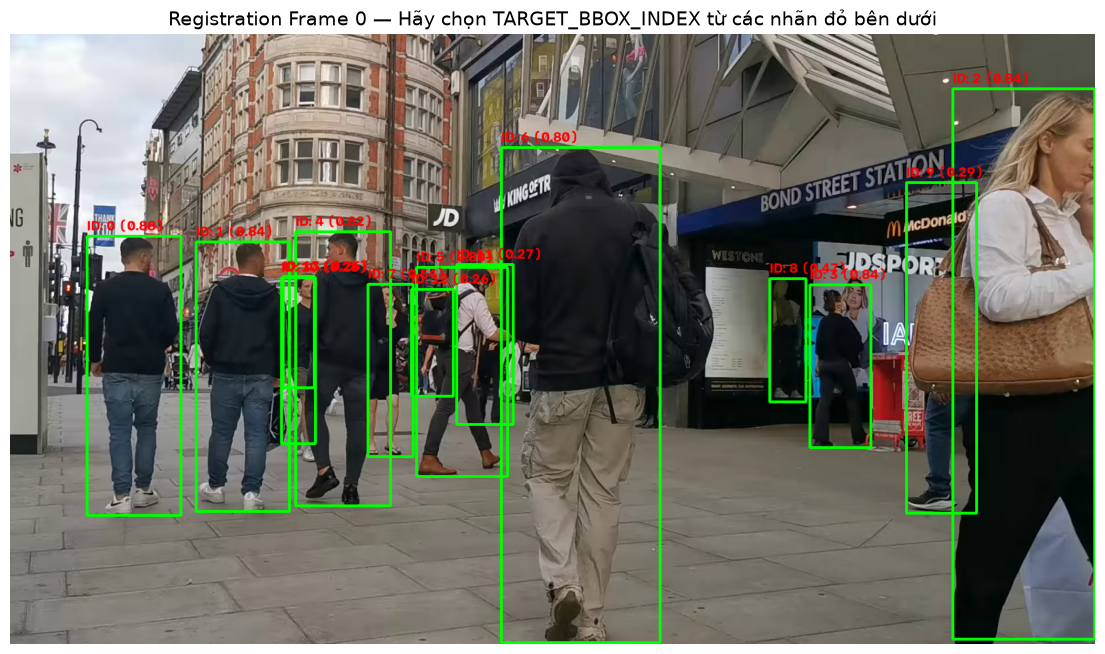

👉 HƯỚNG DẪN:
Quan sát các ô vuông màu đỏ trên ảnh, chọn số Index của người bạn muốn làm Target.
Sau đó điền vào biến TARGET_BBOX_INDEX ở Cell 1 (hoặc gán trực tiếp: TARGET_BBOX_INDEX = <số>) rồi chạy Section 3.


In [4]:
# ==============================================================================
# \U0001f3af SECTION 2: HIỂN THỊ FRAME & GÁN CHỈ SỐ BBOX ỨNG VIÊN
# ==============================================================================
cap = cv2.VideoCapture(RAW_VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, WORKING_START_FRAME + REGISTRATION_FRAME_INDEX)
ret, reg_frame = cap.read()
cap.release()

if not ret or reg_frame is None:
    raise RuntimeError(
        f"Không đọc được frame thứ {REGISTRATION_FRAME_INDEX} (trong khung làm việc) từ '{RAW_VIDEO_PATH}'"
    )

# Detect người (class 0: person trong COCO) — đây là 1 lần detect đơn thuần (không track), nên
# gọi thẳng model ultralytics bên trong YoloDetector (detector.model) thay vì detector.track().
results = detector.model(reg_frame, classes=[0], verbose=False)
detections = []

annotated_frame = reg_frame.copy()
if results and len(results) > 0 and results[0].boxes is not None:
    boxes = results[0].boxes
    for i, box in enumerate(boxes):
        xyxy = box.xyxy[0].cpu().numpy().astype(int)
        conf = float(box.conf[0].cpu().numpy())
        detections.append({
            "index": i,
            "bbox": xyxy,
            "conf": conf
        })
        x1, y1, x2, y2 = xyxy
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
        label = f"ID: {i} ({conf:.2f})"
        cv2.putText(annotated_frame, label, (x1, max(25, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2, cv2.LINE_AA)

print(f"Tìm thấy {len(detections)} người trong frame {REGISTRATION_FRAME_INDEX} (khung làm việc).")
if len(detections) == 0:
    raise ValueError(f"Không tìm thấy người nào trong frame {REGISTRATION_FRAME_INDEX}. Hãy đổi REGISTRATION_FRAME_INDEX!")

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.title(f"Registration Frame {REGISTRATION_FRAME_INDEX} — Hãy chọn TARGET_BBOX_INDEX từ các nhãn đỏ bên dưới", fontsize=14)
plt.axis("off")
plt.show()

print("\U0001f449 HƯỚNG DẪN:")
print(f"Quan sát các ô vuông màu đỏ trên ảnh, chọn số Index của người bạn muốn làm Target.")
print(f"Sau đó điền vào biến TARGET_BBOX_INDEX ở Cell 1 (hoặc gán trực tiếp: TARGET_BBOX_INDEX = <số>) rồi chạy Section 3.")


---
## Section 3: Build Reference Embedding (Single-Frame)
Trích xuất embedding từ đúng crop của bounding box được chọn.


✓ REFERENCE EMBEDDING (SINGLE-FRAME) GENERATED:
  • Shape: (512,)
  • L2-Norm: 1.000000 (Đã L2-normalized đúng)
  • Target BBox: [329, 368, 494, 845]


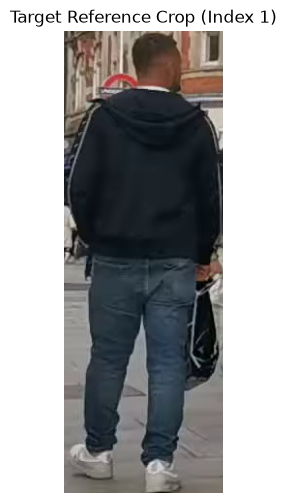

In [6]:
# ==============================================================================
# \U0001f9ec SECTION 3: BUILD REFERENCE EMBEDDING TỪ SINGLE BBOX CROP
# ==============================================================================
TARGET_BBOX_INDEX=1
if TARGET_BBOX_INDEX is None:
    raise ValueError(
        "❌ LỖI: Bạn chưa chọn `TARGET_BBOX_INDEX`!\n"
        "Hãy nhìn hình ảnh ở Section 2, chọn 1 số (ví dụ: TARGET_BBOX_INDEX = 0) và gán giá trị trước khi chạy tiếp."
    )

if TARGET_BBOX_INDEX < 0 or TARGET_BBOX_INDEX >= len(detections):
    raise IndexError(f"TARGET_BBOX_INDEX={TARGET_BBOX_INDEX} không hợp lệ! Danh sách có {len(detections)} bboxes (0 đến {len(detections)-1}).")

target_det = detections[TARGET_BBOX_INDEX]
tx1, ty1, tx2, ty2 = target_det["bbox"]
target_crop = reg_frame[ty1:ty2, tx1:tx2]

if target_crop.size == 0 or target_crop.shape[0] < 10 or target_crop.shape[1] < 10:
    raise ValueError(f"Crop của Target BBox {TARGET_BBOX_INDEX} quá nhỏ hoặc không hợp lệ!")

reference_embedding_single = verifier.extract(target_crop)
emb_norm = np.linalg.norm(reference_embedding_single)

print("==================================================")
print("✓ REFERENCE EMBEDDING (SINGLE-FRAME) GENERATED:")
print(f"  • Shape: {reference_embedding_single.shape}")
print(f"  • L2-Norm: {emb_norm:.6f} (Đã L2-normalized đúng)")
print(f"  • Target BBox: [{tx1}, {ty1}, {tx2}, {ty2}]")
print("==================================================")

plt.figure(figsize=(4, 6))
plt.imshow(cv2.cvtColor(target_crop, cv2.COLOR_BGR2RGB))
plt.title(f"Target Reference Crop (Index {TARGET_BBOX_INDEX})")
plt.axis("off")
plt.show()


---
## Section 4: Track & Verify qua toàn bộ khung làm việc
Chạy YOLOv11 + ByteTrack qua từng frame trong khung làm việc `[START_TIME_SEC, END_TIME_SEC)`.
Tại mỗi frame, trích xuất embedding của mọi track và tính Cosine Similarity thô với
`reference_embedding_single`.


In [7]:
# ==============================================================================
# \U0001f680 SECTION 4: RUN BYTETRACK & COSINE SIMILARITY VERIFICATION
# ==============================================================================
# LƯU Ý QUAN TRỌNG về is_target ở đây: quyết định target/stranger mỗi frame chỉ dựa vào
# similarity RAW của DUY NHẤT frame đó (sim_score >= SIMILARITY_THRESHOLD), KHÔNG có temporal
# smoothing (EMA/voting) và KHÔNG có "chỉ chọn 1 track tốt nhất" như src/pipeline.py thật sự
# dùng khi chạy live. Đây là CHỦ ĐÍCH của ablation này — đo xem single-frame OSNet similarity
# "thô" phân biệt Target/Stranger tốt tới đâu KHI CHƯA có các cơ chế ổn định đó. Video debug
# xuất ra ở cell này vì vậy sẽ trông "nhiễu" hơn hẳn video ở Section 6 — xem giải thích + số
# liệu cụ thể ở Section 7 bên dưới.
if not os.path.exists(RAW_VIDEO_PATH):
    raise FileNotFoundError(f"Không tìm thấy video tại: '{RAW_VIDEO_PATH}'. Hãy chạy Section 1 trước!")

cap = cv2.VideoCapture(RAW_VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, WORKING_START_FRAME)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_frames = WORKING_TOTAL_FRAMES

records = []
perf_records = []  # per-frame timing breakdown (detect_ms/verify_ms/total_ms/num_people) — dùng ở Section 4b
frame_idx = 0
start_time = time.time()

print(f"Bắt đầu tracking và trích xuất similarity trên {total_frames} frames (khung làm việc)...")

video_writer = None
if EXPORT_DEBUG_VIDEO:
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(DEBUG_VIDEO_OUTPUT, fourcc, fps, (w, h))

while frame_idx < total_frames:
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    t_frame_start = time.time()

    # 1. Detect + Track — dùng src.detector.YoloDetector (ByteTrack pinned, xem Cell 2) thay vì
    # gọi ultralytics .track() trực tiếp không chỉ định tracker (chạy BoT-SORT mặc định, nặng hơn).
    t0 = time.time()
    detections_frame = detector.track(frame)  # [{"track_id":..., "bbox":(x1,y1,x2,y2), "confidence":...}, ...]
    detect_ms = (time.time() - t0) * 1000.0

    # 2. Crop + trích xuất embedding — GỘP mọi crop hợp lệ trong frame vào MỘT lần
    # verifier.extract_batch() thay vì gọi verifier.extract() tuần tự từng crop. Đây chính là
    # thay đổi tạo ra khác biệt lớn nhất so với bản gốc của notebook này trên video đông người
    # (trung bình ~9 người/frame trong video mẫu — 9 lần model-launch tuần tự so với 1 lần).
    t0 = time.time()
    valid_dets, valid_crops = [], []
    for det in detections_frame:
        x1, y1, x2, y2 = det["bbox"]
        x1_c, y1_c = max(0, x1), max(0, y1)
        x2_c, y2_c = min(frame.shape[1], x2), min(frame.shape[0], y2)
        crop = frame[y1_c:y2_c, x1_c:x2_c]
        if crop.size > 0 and crop.shape[0] > 10 and crop.shape[1] > 10:
            valid_dets.append(det)
            valid_crops.append(crop)

    embeddings = verifier.extract_batch(valid_crops) if valid_crops else []
    verify_ms = (time.time() - t0) * 1000.0

    for det, emb in zip(valid_dets, embeddings):
        tid = det["track_id"]
        x1, y1, x2, y2 = det["bbox"]
        sim_score = verifier.compare(emb, reference_embedding_single)

        if KNOWN_TARGET_TRACK_ID is not None:
            is_target = (tid == KNOWN_TARGET_TRACK_ID)
        else:
            is_target = (sim_score >= SIMILARITY_THRESHOLD)

        records.append({
            "frame_idx": frame_idx,
            "track_id": tid,
            "similarity_score": round(float(sim_score), 4),
            "is_target": bool(is_target),
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2
        })

        if EXPORT_DEBUG_VIDEO:
            if is_target:
                color = (0, 255, 0)
                thickness = 3
                label = f"TARGET ID:{tid} ({sim_score:.2f})"
            else:
                color = (0, 0, 255)
                thickness = 2
                label = f"ID:{tid} ({sim_score:.2f})"

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
            (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
            cv2.rectangle(frame, (x1, max(0, y1 - 22)), (x1 + lw, y1), color, -1)
            cv2.putText(frame, label, (x1, max(15, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2, cv2.LINE_AA)

    if EXPORT_DEBUG_VIDEO and video_writer:
        overlay_text = f"Frame: {frame_idx}/{total_frames} | Single-Frame Re-ID (RAW, no smoothing)"
        cv2.putText(frame, overlay_text, (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)
        video_writer.write(frame)

    total_ms = (time.time() - t_frame_start) * 1000.0
    perf_records.append({
        "frame_idx": frame_idx, "detect_ms": detect_ms, "verify_ms": verify_ms,
        "total_ms": total_ms, "num_people": len(valid_dets),
    })

    frame_idx += 1
    if frame_idx % 50 == 0 or frame_idx == total_frames:
        elapsed = time.time() - start_time
        print(f"  • Đã xử lý {frame_idx}/{total_frames} frames ({frame_idx/total_frames*100:.1f}%) — {frame_idx/elapsed:.1f} FPS")

cap.release()
if video_writer:
    video_writer.release()
    print(f"✓ Video debug đã lưu tại: {DEBUG_VIDEO_OUTPUT}")

df_results = pd.DataFrame(records)
df_results.to_csv(RESULTS_CSV_PATH, index=False)
print(f"✓ Đã lưu toàn bộ {len(df_results)} detections vào file CSV: '{RESULTS_CSV_PATH}'")


Bắt đầu tracking và trích xuất similarity trên 299 frames (khung làm việc)...
  • Đã xử lý 50/299 frames (16.7%) — 1.1 FPS
  • Đã xử lý 100/299 frames (33.4%) — 1.0 FPS


KeyboardInterrupt: 

---
## Section 4b: Performance Diagnostics — Bottleneck nằm ở đâu?

Notebook gốc chỉ đạt **~1.0-1.3 FPS** trên video đông người này (xem README phần "Hiệu năng").
Section này đo trực tiếp trên máy hiện tại xem sau khi đổi sang ByteTrack (thay BoT-SORT) +
batched OSNet extraction (`extract_batch()` thay vì `extract()` tuần tự), hiệu năng thay đổi ra
sao — và tách riêng chi phí detect vs. verify để biết cái nào đang chiếm phần lớn thời gian mỗi
frame.


In [ ]:
# ==============================================================================
# \U0001f4c8 SECTION 4b.1: TÓM TẮT HIỆU NĂNG ĐO ĐƯỢC (per-stage timing)
# ==============================================================================
df_perf = pd.DataFrame(perf_records)
avg_fps = 1000.0 / df_perf["total_ms"].mean()

print("="*65)
print("\U0001f4ca TÓM TẮT HIỆU NĂNG (đo trực tiếp trên máy này, video đông người)")
print("="*65)
print(f"  • Số frame xử lý:         {len(df_perf)}")
print(f"  • Trung bình người/frame: {df_perf['num_people'].mean():.1f} (tối đa {df_perf['num_people'].max()})")
print(f"  • detect_ms trung bình:   {df_perf['detect_ms'].mean():.1f} ms  (YOLO + ByteTrack)")
print(f"  • verify_ms trung bình:   {df_perf['verify_ms'].mean():.1f} ms  (OSNet — MỌI người trong frame, 1 lần extract_batch())")
print(f"  • total_ms trung bình:    {df_perf['total_ms'].mean():.1f} ms  → ~{avg_fps:.2f} FPS")
print("="*65)
print("LƯU Ý về so sánh 'trước/sau': notebook gốc đo ~1.0-1.3 FPS trên video này (xem README")
print("phần \"Hiệu năng\"), NHƯNG total FPS phụ thuộc rất mạnh vào số người/frame — 1 con số FPS")
print("duy nhất KHÔNG so sánh công bằng giữa 2 lần chạy nếu mật độ người khác nhau (ví dụ lần")
print(f"chạy này trung bình {df_perf['num_people'].mean():.1f} người/frame, có thể khác lần đo gốc). So sánh ĐÁNG TIN")
print("CẬY hơn là phép đo có kiểm soát (cùng 1 frame, cùng máy) ở Section 4b.2 ngay dưới đây,")
print("và phần trăm thời gian detect_ms vs verify_ms chiếm trong total_ms ở trên.")

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
axes[0].plot(df_perf["frame_idx"], df_perf["detect_ms"], label="detect_ms (YOLO+ByteTrack)", color="tab:blue", alpha=0.85)
axes[0].plot(df_perf["frame_idx"], df_perf["verify_ms"], label="verify_ms (OSNet, batched)", color="tab:orange", alpha=0.85)
axes[0].set_ylabel("ms")
axes[0].set_title("Per-stage timing theo từng frame")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.5)

axes[1].plot(df_perf["frame_idx"], df_perf["num_people"], color="tab:green", alpha=0.85)
axes[1].set_ylabel("Số người/frame")
axes[1].set_xlabel("Frame Index")
axes[1].set_title("Số người detect được mỗi frame (verify_ms tỉ lệ thuận với số này)")
axes[1].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# ⚖️ SECTION 4b.2: BEFORE vs AFTER — Batched vs Sequential OSNet (đo trên crop THẬT của video)
# ==============================================================================
busiest_idx = int(df_perf.loc[df_perf["num_people"].idxmax(), "frame_idx"])
cap = cv2.VideoCapture(RAW_VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, WORKING_START_FRAME + busiest_idx)
ret, busy_frame = cap.read()
cap.release()

busy_dets = detector.track(busy_frame)
busy_crops = []
for det in busy_dets:
    x1, y1, x2, y2 = det["bbox"]
    x1c, y1c = max(0, x1), max(0, y1)
    x2c, y2c = min(busy_frame.shape[1], x2), min(busy_frame.shape[0], y2)
    c = busy_frame[y1c:y2c, x1c:x2c]
    if c.size > 0 and c.shape[0] > 10 and c.shape[1] > 10:
        busy_crops.append(c)

print(f"Frame đông người nhất trong khung làm việc: frame {busiest_idx} với {len(busy_crops)} người.\n")

verifier.extract(busy_crops[0])  # warm-up (chi phí lazy-init lần gọi đầu, không tính vào đo)

seq_trials, batch_trials = [], []
for _ in range(3):
    t0 = time.time()
    for c in busy_crops:
        verifier.extract(c)
    seq_trials.append(time.time() - t0)

    t0 = time.time()
    verifier.extract_batch(busy_crops)
    batch_trials.append(time.time() - t0)

seq_ms = statistics.median(seq_trials) * 1000
batch_ms = statistics.median(batch_trials) * 1000
print(f"  • Sequential verifier.extract() x{len(busy_crops)} lần: {seq_ms:.1f} ms (median/3 lần đo)")
print(f"  • Batched    verifier.extract_batch() 1 lần:          {batch_ms:.1f} ms (median/3 lần đo)")
print(f"  • Speedup đo được trên MÁY NÀY: {seq_ms/batch_ms:.2f}x")
print()
print("Lưu ý: batching KHÔNG phải phép màu — tổng FLOPs của OSNet như nhau, chỉ tiết kiệm chi phí")
print("Python/PIL/preprocessing lặp lại N lần. Mức tăng tốc thực đo được (xem test_verifier.py để")
print("tái lập) dao động ~1.1-1.4x tuỳ máy/batch size — KHÔNG phải đòn bẩy lớn nhất.")
print()
print("Đòn bẩy LỚN hơn nhiều là `verify_every_n_frames` (src/pipeline.py, config/settings.yaml) —")
print("KHÔNG bật ở notebook này để giữ nguyên phép đo similarity 'MỌI frame' cho Section 5, nhưng")
print("với trung bình quan sát được ở khung làm việc này:")
avg_people = df_perf["num_people"].mean()
n = 3
reduced_calls = 1 + (avg_people - 1) / n
print(f"  • {avg_people:.1f} người/frame trung bình → {avg_people:.1f} lần gọi OSNet/frame hiện tại.")
print(f"  • Với verify_every_n_frames={n} (chỉ active target luôn verify mỗi frame, còn lại verify")
print(f"    mỗi {n} frame, tái sử dụng raw_score giữa các lần — xem test_pipeline.py để xem cơ chế")
print(f"    này đã được unit-test): trung bình còn ~{reduced_calls:.1f} lần gọi OSNet/frame")
print(f"    → giảm ~{avg_people/reduced_calls:.1f}x chi phí verify, GẦN NHƯ MIỄN PHÍ về accuracy vì")
print(f"    ByteTrack đã tự giữ track_id giữa các frame liên tiếp.")


---
## Section 5: Visualize & Phân tích Phân phối Similarity
1. Vẽ biểu đồ biến thiên similarity theo thời gian cho từng `track_id`.
2. Phân tích phân phối và tính toán `inter-class gap` khi xác định được Target Track ID.


In [ ]:
# ==============================================================================
# \U0001f4ca SECTION 5: VISUALIZE SIMILARITY & PHÂN TÍCH THỐNG KÊ
# ==============================================================================
if not os.path.exists(RESULTS_CSV_PATH):
    raise FileNotFoundError(f"Không tìm thấy file kết quả CSV: '{RESULTS_CSV_PATH}'")

df = pd.read_csv(RESULTS_CSV_PATH)
if df.empty:
    raise ValueError("File CSV không có dữ liệu detection nào!")

unique_tracks = df["track_id"].unique()
print(f"Tổng số track_id xuất hiện trong video: {len(unique_tracks)} (Tracks: {list(unique_tracks)})")

plt.figure(figsize=(15, 6))
for tid in sorted(unique_tracks):
    track_df = df[df["track_id"] == tid]
    if len(track_df) >= 3:
        plt.plot(track_df["frame_idx"], track_df["similarity_score"], label=f"Track ID {tid}", marker='.', markersize=4, alpha=0.8)

plt.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Ref Threshold (0.80)')
plt.title("Single-Frame OSNet Similarity Score qua từng Frame (Mỗi đường là 1 Track ID)", fontsize=14)
plt.xlabel("Frame Index", fontsize=12)
plt.ylabel("Cosine Similarity Score [-1.0, 1.0]", fontsize=12)
plt.ylim(-0.2, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0), fontsize=9)
plt.tight_layout()
plt.show()

print("\U0001f449 HƯỚNG DẪN:")
print("Quan sát biểu đồ trên, tìm track_id có similarity cao liên tục (chính là Target).")
print("Sau đó gán `KNOWN_TARGET_TRACK_ID = <số track_id>` để xem histogram và bảng số liệu.")

if KNOWN_TARGET_TRACK_ID is not None:
    target_scores = df[df["track_id"] == KNOWN_TARGET_TRACK_ID]["similarity_score"]
    stranger_scores = df[df["track_id"] != KNOWN_TARGET_TRACK_ID]["similarity_score"]

    if len(target_scores) == 0:
        print(f"⚠️ Cảnh báo: Track ID {KNOWN_TARGET_TRACK_ID} không tồn tại trong dữ liệu!")
    else:
        plt.figure(figsize=(10, 5))
        plt.hist(stranger_scores, bins=30, alpha=0.6, color='red', label=f'Strangers (N={len(stranger_scores)})', density=True)
        plt.hist(target_scores, bins=20, alpha=0.7, color='green', label=f'Target ID {KNOWN_TARGET_TRACK_ID} (N={len(target_scores)})', density=True)
        plt.title(f"Phân phối Similarity: Target vs Strangers (Single-Frame Reference)", fontsize=14)
        plt.xlabel("Cosine Similarity Score", fontsize=12)
        plt.ylabel("Mật độ (Density)", fontsize=12)
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.legend(fontsize=11)
        plt.show()

        t_mean, t_std, t_median = target_scores.mean(), target_scores.std(), target_scores.median()
        s_mean, s_std, s_median = stranger_scores.mean(), stranger_scores.std(), stranger_scores.median()
        gap = t_mean - s_mean

        stats_data = {
            "Metric": ["Mean Similarity", "Median Similarity", "Std Deviation", "Min Similarity", "Max Similarity", "Sample Count (N)"],
            f"Target (Track {KNOWN_TARGET_TRACK_ID})": [f"{t_mean:.4f}", f"{t_median:.4f}", f"{t_std:.4f}", f"{target_scores.min():.4f}", f"{target_scores.max():.4f}", len(target_scores)],
            "Strangers (All other tracks)": [f"{s_mean:.4f}", f"{s_median:.4f}", f"{s_std:.4f}", f"{stranger_scores.min():.4f}", f"{stranger_scores.max():.4f}", len(stranger_scores)],
        }
        df_stats = pd.DataFrame(stats_data)
        print("\n" + "="*65)
        print("\U0001f4ca BẢNG THỐNG KÊ CHI TIẾT (SINGLE-FRAME REGISTRATION):")
        print("="*65)
        print(df_stats.to_string(index=False))
        print("-" * 65)
        print(f"⭐ Inter-Class Separation Gap (Target Mean - Stranger Mean): {gap:+.4f}")
        print("="*65)


---
## Section 6: Xuất Video Kết Quả Hoàn Chỉnh (Annotated Target Video)
Tạo video chất lượng cao hiển thị trực quan:
- \U0001f7e2 **Bounding box Xanh lá (Green)**: Cho người được theo dõi (Target Track ID / similarity cao nhất).
- \U0001f534 **Bounding box Đỏ (Red)**: Cho tất cả người lạ hoặc ID không được chọn (Untracked / Strangers).
- Hiển thị bảng HUD trạng thái tracking và Cosine Similarity trực tiếp trên khung hình.

⚠️ **Đọc kỹ trước khi so sánh với video debug ở Section 4**: video này KHÔNG phải mô phỏng một
hệ thống real-time. `active_target_id` được chọn bằng cách lấy **similarity trung bình trên
TOÀN BỘ khung làm việc** (`df.groupby("track_id")["similarity_score"].mean()`) — tức là dùng
thống kê tổng hợp của TƯƠNG LAI (toàn bộ frame trong khung làm việc) để quyết định, thứ một hệ
thống chạy live tại frame thứ N không thể biết được. Vì chỉ vẽ đúng 1 ID xanh lá xuyên suốt,
video này trông "sạch" hơn hẳn — đó là do nó dùng thông tin mà một hệ thống causal (chạy
real-time) không có, KHÔNG phải vì cơ chế phát hiện target tốt hơn. Xem Section 7 để so sánh
định lượng với video debug.


In [ ]:
# ==============================================================================
# \U0001f3ac SECTION 6: RENDER ANNOTATED VIDEO (GREEN = TARGET, RED = UNTRACKED)
# ==============================================================================
ANNOTATED_VIDEO_PATH = os.path.join(OUTPUT_DIR, "output_single_frame_annotated.mp4")

if not os.path.exists(RESULTS_CSV_PATH):
    raise FileNotFoundError(f"Không tìm thấy file kết quả CSV: '{RESULTS_CSV_PATH}'. Hãy chạy Section 4 trước!")

df_res = pd.read_csv(RESULTS_CSV_PATH)
if df_res.empty:
    raise ValueError("Dữ liệu kết quả trống!")

active_target_id = KNOWN_TARGET_TRACK_ID
if active_target_id is None:
    avg_scores = df_res.groupby("track_id")["similarity_score"].agg(["mean", "count"])
    avg_scores = avg_scores[avg_scores["count"] >= 5]
    if not avg_scores.empty:
        active_target_id = int(avg_scores["mean"].idxmax())
        print(f"ℹ️ Tự động nhận diện Target Track ID có similarity cao nhất: ID = {active_target_id} (Mean Sim: {avg_scores.loc[active_target_id, 'mean']:.4f})")
    else:
        active_target_id = int(df_res.groupby("track_id")["similarity_score"].mean().idxmax())
        print(f"ℹ️ Chọn Track ID cao nhất: ID = {active_target_id}")
else:
    print(f"ℹ️ Sử dụng KNOWN_TARGET_TRACK_ID đã chỉ định: ID = {active_target_id}")

cap = cv2.VideoCapture(RAW_VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, WORKING_START_FRAME)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = WORKING_TOTAL_FRAMES

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = cv2.VideoWriter(ANNOTATED_VIDEO_PATH, fourcc, fps, (w, h))

print(f"Đang render video chú thích hoàn chỉnh tới '{ANNOTATED_VIDEO_PATH}'...")

frame_idx = 0
while frame_idx < total_frames:
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    frame_df = df_res[df_res["frame_idx"] == frame_idx]

    target_present = False
    for _, row in frame_df.iterrows():
        tid = int(row["track_id"])
        sim = float(row["similarity_score"])
        x1, y1 = int(row["bbox_x1"]), int(row["bbox_y1"])
        x2, y2 = int(row["bbox_x2"]), int(row["bbox_y2"])

        is_target = (tid == active_target_id)
        if is_target:
            target_present = True
            box_color = (0, 255, 0)
            thickness = 3
            label = f"TARGET ID:{tid} (Sim: {sim:.2f})"
        else:
            box_color = (0, 0, 255)
            thickness = 2
            label = f"ID:{tid} ({sim:.2f})"

        cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, thickness)
        (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(frame, (x1, max(0, y1 - 22)), (x1 + lw, y1), box_color, -1)
        cv2.putText(frame, label, (x1, max(15, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2, cv2.LINE_AA)

    hud_bg = frame.copy()
    cv2.rectangle(hud_bg, (0, 0), (w, 50), (20, 20, 20), -1)
    cv2.addWeighted(hud_bg, 0.6, frame, 0.4, 0, frame)

    status_text = f"TRACKING TARGET ID: {active_target_id}" if target_present else "TARGET: SEARCHING / OCCLUDED"
    status_color = (0, 255, 0) if target_present else (0, 165, 255)
    cv2.putText(frame, status_text, (20, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2, cv2.LINE_AA)
    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (w - 240, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)

    out_writer.write(frame)
    frame_idx += 1

cap.release()
out_writer.release()

print("="*60)
print(f"✓ Video kết quả chú thích đã được lưu thành công tại:")
print(f"  \U0001f449 {ANNOTATED_VIDEO_PATH}")
print(f"  • \U0001f7e2 Xanh lá: Target Person (ID {active_target_id})")
print(f"  • \U0001f534 Đỏ: Untracked / Strangers")
print("="*60)


---
## Section 7: Vì sao video Debug (Section 4) trông tệ hơn hẳn video Annotated (Section 6)?

Cả hai video render từ **cùng một** `results_single_frame.csv`. Khác biệt duy nhất là cách
chọn "ai là target ở frame này":

| | Section 4 (Debug) | Section 6 (Annotated) |
|---|---|---|
| Nguồn quyết định | `similarity_score` CỦA RIÊNG frame đó, so với `SIMILARITY_THRESHOLD` | `mean(similarity_score)` trên **toàn bộ khung làm việc** |
| Có thể chạy real-time? | ✅ Có — chỉ cần dữ liệu tới thời điểm hiện tại | ❌ Không — cần biết trước TOÀN BỘ khung làm việc |
| Số track có thể "xanh" cùng lúc | Không giới hạn (mỗi track tự so ngưỡng độc lập) | Luôn đúng 1 (track có mean cao nhất) |
| Có temporal smoothing? | Không (đây là chủ đích của ablation) | Không cần — đã "cheat" bằng thống kê toàn cục |

Nói cách khác: Section 6 không chứng minh single-frame OSNet "đủ tốt" — nó chỉ vẽ lại đáp án
đúng mà ta đã biết trước bằng mắt thường. Section 4 mới là thứ một hệ thống thật (`main.py
--mode run`) sẽ thực sự phải đối mặt tại **mỗi frame, không có thông tin tương lai**. Cell dưới
đây định lượng chính xác sự khác biệt đó bằng dữ liệu thật của lần chạy này, rồi cho xem thêm
temporal smoothing (cơ chế thật sự dùng trong `src/pipeline.py`) khắc phục nó tới đâu.


In [ ]:
# ==============================================================================
# \U0001f50d SECTION 7: ĐỊNH LƯỢNG SỰ KHÁC BIỆT — RAW (Section 4) vs SMOOTHED (mô phỏng pipeline.py)
# ==============================================================================
df7 = pd.read_csv(RESULTS_CSV_PATH)
df7["is_target_raw"] = df7["similarity_score"] >= SIMILARITY_THRESHOLD

per_frame_pass = df7.groupby("frame_idx")["is_target_raw"].sum()
multi_pct = (per_frame_pass > 1).mean() * 100
zero_pct = (per_frame_pass == 0).mean() * 100

print("="*70)
print("\U0001f4ca 1. VIDEO DEBUG (Section 4) THỰC SỰ TRÔNG NHƯ THẾ NÀO — đo trên toàn bộ khung làm việc:")
print("="*70)
print(f"  • {multi_pct:.1f}% số frame có ≥2 track CÙNG vượt ngưỡng {SIMILARITY_THRESHOLD}")
print(f"    (nghĩa là ≥2 box XANH xuất hiện đồng thời — không phải bug, đây chính xác là những")
print(f"    gì raw per-frame thresholding tạo ra khi không có cơ chế 'chỉ 1 target' như pipeline.py)")
print(f"  • {zero_pct:.1f}% số frame KHÔNG có track nào vượt ngưỡng (không có box xanh nào,")
print(f"    kể cả ở những frame target thật sự đang hiện diện rõ ràng trong khung hình)")
print()

real_target_id = KNOWN_TARGET_TRACK_ID if KNOWN_TARGET_TRACK_ID is not None else active_target_id
t = df7[df7["track_id"] == real_target_id].sort_values("frame_idx").reset_index(drop=True)

if len(t) > 1:
    flips_raw = int((t["is_target_raw"].astype(int).diff().abs() == 1).sum())
    below_pct_raw = (~t["is_target_raw"]).mean() * 100

    EMA_ALPHA = 0.3
    smoothed_scores = []
    prev = None
    for s in t["similarity_score"]:
        prev = s if prev is None else EMA_ALPHA * s + (1 - EMA_ALPHA) * prev
        smoothed_scores.append(prev)
    t["is_target_smoothed"] = pd.Series(smoothed_scores) >= SIMILARITY_THRESHOLD
    flips_smoothed = int((t["is_target_smoothed"].astype(int).diff().abs() == 1).sum())
    below_pct_smoothed = (~t["is_target_smoothed"]).mean() * 100

    print("="*70)
    print(f"\U0001f4ca 2. TRACK {real_target_id} (target thật, có mặt {len(t)}/{df7['frame_idx'].nunique()} frame):")
    print("="*70)
    print(f"  {'Metric':<45}{'RAW (Section 4)':>15}{'EMA α=0.3':>12}")
    print(f"  {'-'*45}{'-'*15}{'-'*12}")
    print(f"  {'Số lần flicker qua lại ngưỡng':<45}{flips_raw:>15}{flips_smoothed:>12}")
    print(f"  {'% frame tự rớt dưới ngưỡng':<45}{below_pct_raw:>14.1f}%{below_pct_smoothed:>11.1f}%")
    print()
    print(f"  → Chỉ thêm EMA (1 dòng công thức, đúng cơ chế `src/pipeline.py` dùng khi")
    print(f"    verification_smoothing.mode='ema') đã giảm flicker từ {flips_raw} xuống {flips_smoothed} lần —")
    print(f"    không cần đổi model, không cần đổi threshold.")
else:
    print(f"⚠️ Track {real_target_id} không đủ dữ liệu (>1 frame) để phân tích flicker. "
          f"Hãy đặt KNOWN_TARGET_TRACK_ID ở Cell 1 rồi chạy lại Section 4/5/6/7.")

print()
print("="*70)
print("\U0001f4ca 3. FALSE-POSITIVE RATE CỦA CÁC TRACK 'STRANGER' (không phải target thật):")
print("="*70)
stranger_ids = [tid for tid in df7["track_id"].unique() if tid != real_target_id]
stranger_stats = (
    df7[df7["track_id"].isin(stranger_ids)]
    .groupby("track_id")
    .agg(n_frames=("similarity_score", "size"), mean_sim=("similarity_score", "mean"),
         pct_over_threshold=("is_target_raw", "mean"))
    .query("n_frames >= 30")
    .sort_values("pct_over_threshold", ascending=False)
)
stranger_stats["pct_over_threshold"] = (stranger_stats["pct_over_threshold"] * 100).round(1)
stranger_stats["mean_sim"] = stranger_stats["mean_sim"].round(4)
print(stranger_stats.head(10).to_string())
print()
print(f"→ Đây chính là 'inter-class gap' yếu mà Section 5 đo được bằng con số: strangers có")
print(f"  similarity trung bình RẤT gần ngưỡng {SIMILARITY_THRESHOLD}, nên chỉ cần nhiễu single-frame")
print(f"  bình thường (góc quay, mờ chuyển động, ánh sáng) là đủ để họ thỉnh thoảng vượt ngưỡng.")
